In [5]:
import os

import numpy as np
from fink_utils.sso.spins import func_hg1g2
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import duckdb
from fink_utils.sso.spins import (func_hg1g2, estimate_sso_params)


from matplotlib.lines import Line2D
markers = list(Line2D.markers.keys())

from matplotlib import lines
lines = list(lines.lineStyles.keys())

import pandas as pd


In [6]:
def G12_to_G1G2(g12):
    """
    Convert a single G12 value or array of G12 values to corresponding G1 and G2 values.
    See Muino et al. (2012) and Pentilla et al. (2018) for details.
    
    Parameters
    ----------
    g12 : float or array-like
        The G12 value(s) to convert.

    Returns
    -------
    G1 : float or np.ndarray
        The computed G1 value(s).
    G2 : float or np.ndarray
        The computed G2 value(s).
    """
    G1_a, G2_a = 0.0, 0.53513350
    G1_b, G2_b = 0.84293649, -0.53513350

    G1 = G1_a + g12 * G1_b
    G2 = G2_a + g12 * G2_b

    return G1, G2

In [7]:
data = pd.read_csv( os.path.join( '..','..','data','Mahlke2021_G1G2.csv'))

path_mpc_db = os.path.join('/', 'data', 'mpcatobs', 'mpc_observations2.duckdb' )
path_eph_db = os.path.join('/', 'data', 'mpcatobs', 'miriade.db' )

In [8]:
phase = np.linspace(0, 35, 100)
phase_rad = np.radians(phase)

In [9]:
data = pd.DataFrame({'tax': ["E", "S", "C", "D"]})
data['g1_c'] = [ 0.1,0.3,0.6,0.9]
data['g2_c'] = [ 0.8,0.4,0.2,0.05]

E G1G2: -0.241, -0.200  RMS: 0.030 0.030 
S G1G2:  0.010,  0.106  RMS: 0.034 0.033 
C G1G2:  0.284,  0.022  RMS: 0.034 0.033 
D G1G2:  0.709, -0.092  RMS: 0.033 0.032 


(0.0, 1.0)

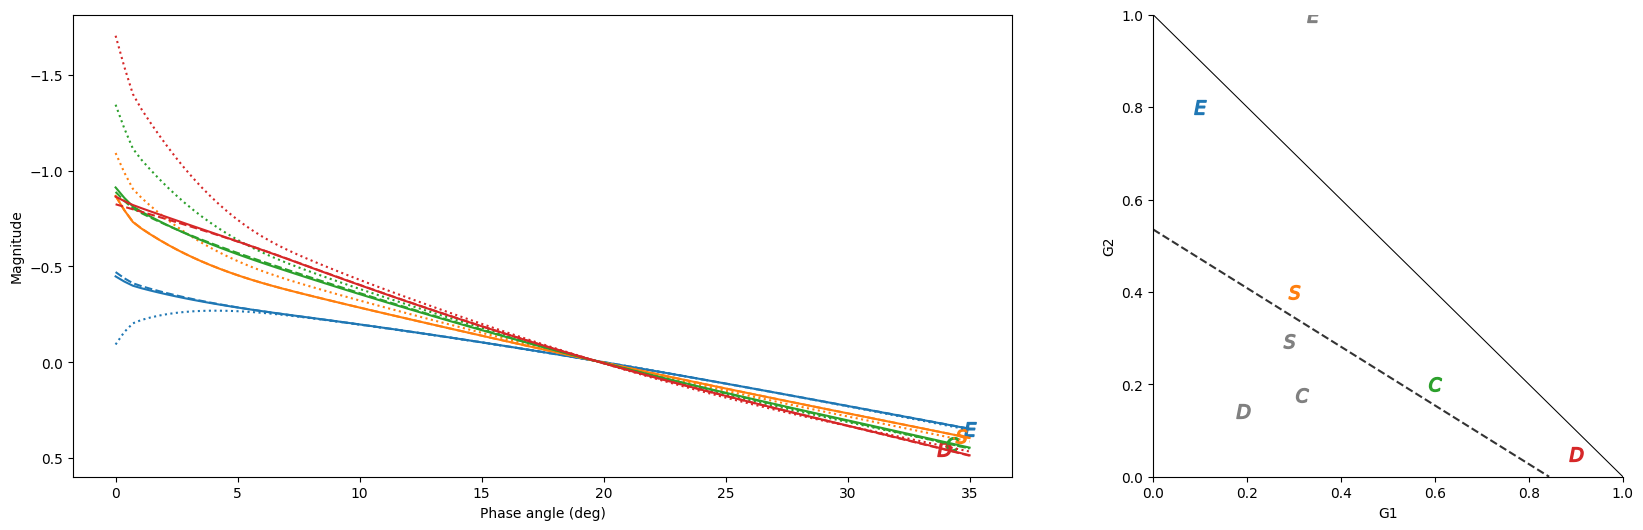

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6), width_ratios=(2, 1))

# --------------------------------------------------------------------------------
# for i, g12 in enumerate(np.linspace(0, 1, num=5)):
for i, row in data.iterrows():

    # Generate phase curve
    H, G1, G2 = 0, row['g1_c'], row['g2_c']
    HGG = func_hg1g2(phase_rad, H, G1, G2)
    color = f'C{i % 8}'  # Cycle through colors

    
    # Normalization
    wn = np.where( (phase >= 15) & (phase<=25) )
    HGG = HGG - np.mean(HGG[wn])

    ax[0].plot(phase, HGG, c=color)
    ax[0].scatter(phase[-1-i], HGG[-1-i], c=color, s=100, marker=f"${row['tax']}$")
    ax[1].scatter(G1, G2, c=color, s=100, marker=f"${row['tax']}$")

    # Add some Gaussian noise
    HGG_noisy = HGG + np.random.normal(0, 0.035, size=HGG.shape)

    # Fit
    fit = estimate_sso_params(
        HGG_noisy,
        np.zeros_like(HGG)*0+0.05,
        phase_rad,
        np.zeros_like(HGG, dtype=int)+1,
        model="HG1G2",
    )

    pred_HGG = func_hg1g2(phase_rad, H, fit['G1_1'], fit['G2_1'])
    pred_HGG = pred_HGG - np.mean(pred_HGG[wn])
    ax[0].plot(phase, pred_HGG, c=color, linestyle='--', label=f"{row['tax']} fit")


    # Truncated fit
    lpa = np.where( (phase >= 15) & (phase<=35) )
    trunk_fit = estimate_sso_params(
        HGG_noisy[lpa],
        np.zeros_like(HGG[lpa])*0+0.05,
        phase_rad[lpa],
        np.zeros_like(HGG[lpa], dtype=int)+1,
        model="HG1G2",
    )

    pred_trunk_HGG = func_hg1g2(phase_rad, H, trunk_fit['G1_1'], trunk_fit['G2_1'])
    pred_trunk_HGG = pred_trunk_HGG - np.mean(pred_trunk_HGG[wn])
    ax[0].plot(phase, pred_trunk_HGG, c=color, linestyle=':', label=f"{row['tax']} trunk fit")
    
    print( f"{row['tax']} "\
        #   f"Full: {row['g1_c']-fit['G1_1']:6.3f}, {row['g2_c']-fit['G2_1']:6.3f}   "\
          f"G1G2: {row['g1_c']-trunk_fit['G1_1']:6.3f}, {row['g2_c']-trunk_fit['G2_1']:6.3f}  "\
        #   f"Full:  {np.sqrt(np.mean( (HGG - pred_HGG)**2 ) ):.3f} {np.sqrt(np.mean( (HGG - pred_trunk_HGG)**2 ) ):.3f} "\
        #   f"RMS: {np.sqrt(np.mean( (HGG[lpa] - pred_HGG[lpa])**2 ) ):.3f} {np.sqrt(np.mean( (HGG[lpa] - pred_trunk_HGG[lpa])**2 ) ):.3f} ")
          f"RMS: {np.sqrt(np.mean( (HGG_noisy[lpa] - pred_HGG[lpa])**2 ) ):.3f} {np.sqrt(np.mean( (HGG_noisy[lpa] - pred_trunk_HGG[lpa])**2 ) ):.3f} ")
    ax[1].scatter(trunk_fit['G1_1'], trunk_fit['G2_1'], c='grey', s=100, marker=f"${row['tax']}$")

# --------------------------------------------------------------------------------
# Axes
# Phase curve
ax[0].set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Magnitude")
ax[0].invert_yaxis()

# G1 G2 space
xx = np.linspace(0, 1, num=5)
x, y = G12_to_G1G2(xx)
ax[1].plot(x, y, linestyle="--", color="black", alpha=0.8)

ax[1].plot([0, 1], [1, 0], color="black", lw=0.75)
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].set_xlabel("G1")
ax[1].set_ylabel("G2")
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)

E  0.021    0.000
S  0.038    0.000
C  0.015    0.000
D  0.049    0.000


(-0.02, 0.02)

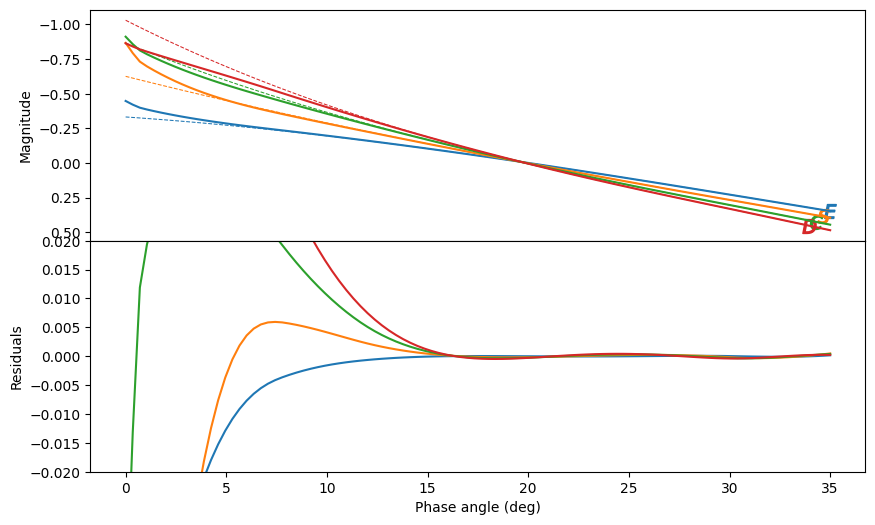

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'hspace': 0.})

# --------------------------------------------------------------------------------
# for i, g12 in enumerate(np.linspace(0, 1, num=5)):
for i, row in data.iterrows():

    G1, G2 = row['g1_c'], row['g2_c']
    HGG = func_hg1g2(phase_rad, H, G1, G2)
    
    # Test normalization
    wn = np.where( (phase >= 15) & (phase<=25) )
    HGG = HGG - np.mean(HGG[wn])


    color = f'C{i % 8}'  # Cycle through colors

    # ax[0].plot(phase, HGG, c=color, linestyle=lines[i % len(lines)], label=row['tax'])
    ax[0].plot(phase, HGG, c=color)
    ax[0].scatter(phase[-1-i], HGG[-1-i], c=color, s=100, marker=f"${row['tax']}$")


    lpa = np.where( (phase >= 15) & (phase<=35) )
    x = phase[lpa]
    y = HGG[lpa]
    
    z = np.polyfit(x, y, 3)
    pred = np.polyval(z, phase)
    ax[0].plot(phase, pred, c=color, linestyle='--', lw=0.75)
    print( f"{row['tax']:1s}  {np.sqrt(np.mean( (HGG - pred)**2 ) ):.3f}    {np.sqrt(np.mean( (HGG[lpa] - pred[lpa])**2 ) ):.3f}" )

    # Fit a linear regression model to the data
    # reg = LinearRegression().fit(x.reshape(-1, 1), y)
    # pred = reg.predict(phase.reshape(-1, 1))
    # ax[0].plot(phase, pred, c=color, linestyle='--', lw=0.75)

    ax[1].plot(phase, HGG-pred, c=color) 





# --------------------------------------------------------------------------------
# Axes
# Phase curve
ax[1].set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Magnitude")
ax[0].invert_yaxis()

ax[1].set_ylabel("Residuals")
ax[1].set_ylim(np.array([-1,1])*0.02)



# MPC DB

In [16]:
# Connect to the database
with duckdb.connect(path_mpc_db) as con:
    
    sql = f"""
            SELECT 
            obsid, band, ra, dec, mag, obstime, stn, IAU_designation
            FROM asteroids_obs
            WHERE stn = 'C57'
        """
    tess = con.execute(sql).fetchdf()


In [ ]:
sel = tess.IAU_designation.value_counts()>100
cond = tess.IAU_designation.isin(sel[sel].index.tolist())

targets = tess.loc[cond,'IAU_designation'].sample(1000, random_state=42)
phase_df = pd.DataFrame({"IAU_designation": targets})

In [75]:
bins = np.linspace(0, 35, 36)


for i, row in phase_df.iterrows():
    target = row['IAU_designation']
    
    # Connect to the database
    with duckdb.connect(path_eph_db) as con:
        
        # print(f"Asteroid ID for identifier '{identifier}': {provisional_designation}")
        sql = f"""
                SELECT * 
                FROM miriade.miriade_observations
                WHERE IAU_designation = '{target}'
            """
        eph = con.execute(sql).fetchdf()
    

    if eph.empty:
        continue
    else:
        phase_df.loc[i, 'n_obs'] = eph.shape[0]
        phase_df.loc[i, 'min_phase'] = eph['Phase'].min()
        phase_df.loc[i, 'max_phase'] = eph['Phase'].max()
        phase_df.loc[i, 'mean_phase'] = eph['Phase'].mean()
        
        n,h = np.histogram( eph.Phase, bins=bins)
        phase_df.loc[i, h[:-1]] = n


Text(0.5, 0, 'Phase angle (deg)')

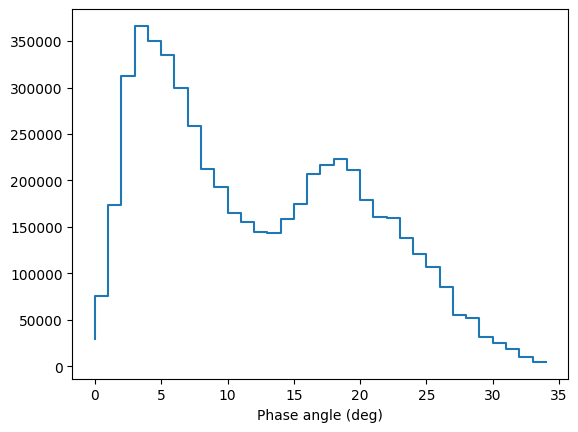

In [76]:
fig, ax = plt.subplots()

bins = np.linspace(0, 35, 36)
# ax.hist( phase_df['min_phase'], bins=bins, cumulative=True, label='min phase', alpha=0.5 )
# ax.hist( phase_df['max_phase'], bins=bins, cumulative=True, label='min phase', alpha=0.5 )
# ax.hist( phase_df['mean_phase'], bins=bins, cumulative=True, label='min phase', alpha=0.5 )

ax.step( bins[:-1], phase_df[h[:-1]].sum(axis=0))


ax.set_xlabel("Phase angle (deg)")

In [48]:
len(h[:-1])

35

In [45]:
        phase_df.loc[i, [0,1]] = n[:2]


In [46]:
phase_df

,IAU_designation,n_obs,min_phase,max_phase,mean_phase,0,1
0,A886 VA,17939.0,0.094838,29.753796,16.690569,NaN,NaN
1,1927 WC,17796.0,1.290777,29.931478,15.576102,NaN,NaN
2,1938 DF,16397.0,0.380948,30.803398,17.519552,NaN,NaN
3,A913 EK,17057.0,0.826376,30.542532,14.603864,NaN,NaN
4,A912 CE,17172.0,0.576575,23.893375,14.010091,NaN,NaN
...,...,...,...,...,...,...,...
95,1983 AE2,11710.0,0.356134,20.821252,15.064308,NaN,NaN
96,1965 AK1,12048.0,0.420387,21.055854,14.601769,NaN,NaN
97,1930 SP,12622.0,0.355813,35.714798,14.411530,NaN,NaN
98,1972 GL,11825.0,0.464864,30.270234,18.531803,NaN,NaN


In [24]:
# Connect to the database
with duckdb.connect(path_eph_db) as con:
    
    # print(f"Asteroid ID for identifier '{identifier}': {provisional_designation}")
    sql = f"""
            SELECT * 
            FROM miriade.miriade_observations
            WHERE IAU_designation = '{target}'
        """
    eph = con.execute(sql).fetchdf()


In [25]:
eph

,Date,RA,DEC,Dobs,Dhelio,VMag,Phase,Elong.,dRAcosDEC,dDEC,RV,obsid,IAU_designation
0,2.434131e+06,+15:14:03.7362,-16:55:46.145,1.066513,2.062008,15.706544,5.883501,167.884356,-0.641247,-0.052287,-3.029796,00000000_00_000YlNx,1972 GL
1,2.435187e+06,+10:34:19.0679,+22:55:37.396,1.092299,2.015014,16.059381,14.508240,149.543206,-0.469737,-0.064083,7.546055,00000000_00_000YlNy,1972 GL
2,2.435187e+06,+10:34:18.9460,+22:55:37.166,1.092310,2.015014,16.059441,14.509359,149.540701,-0.469697,-0.064114,7.546917,00000000_00_000YlNz,1972 GL
3,2.435187e+06,+10:34:16.9947,+22:55:33.471,1.092484,2.015001,16.060406,14.527273,149.500579,-0.469058,-0.064615,7.560726,00000000_00_000YlO0,1972 GL
4,2.441422e+06,+13:59:46.9577,-06:23:40.388,1.030755,2.030144,15.473414,3.553305,172.796411,-0.671248,0.025009,-1.237426,Gsj000000000DknH01000000m,1972 GL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11820,2.460795e+06,+07:22:52.6634,+29:27:00.055,2.191766,2.067432,18.028468,27.151455,69.531259,1.048798,-0.233764,16.540103,LnxAu24y0000Gprg01000005W,1972 GL
11821,2.460796e+06,+07:24:48.8039,+29:21:19.925,2.201320,2.066593,18.034546,27.066803,68.994837,1.054451,-0.237589,16.467279,LnyAuB9w0000Gpy4010000047,1972 GL
11822,2.460796e+06,+07:24:49.0739,+29:21:19.130,2.201342,2.066591,18.034560,27.066604,68.993596,1.054464,-0.237598,16.467109,LnyAuB9w0000Gpy4010000048,1972 GL
11823,2.460796e+06,+07:24:49.3439,+29:21:18.334,2.201364,2.066589,18.034574,27.066405,68.992355,1.054477,-0.237607,16.466938,LnyAuB9w0000Gpy4010000049,1972 GL


In [ ]:
pl

In [ ]:
MPC_TABLE_IDENTIFIERS = "asteroids_identifiers"
MPC_TABLE_OBSERVATIONS = "asteroids_obs"

# Connect to the database
with duckdb.connect(path_mpc_db) as con:
    # Query to count all objects from the MPC database
    query = f"SELECT COUNT(*) FROM {MPC_TABLE_OBSERVATIONS}"
    result = con.execute(query).fetchone()
    print(f"Total number of observations: {result[0]}")

    # Example query to fetch some data
    query = f"SELECT * FROM {MPC_TABLE_OBSERVATIONS} LIMIT 100"
    df_obs = con.execute(query).fetchdf()
    print(df_obs.head())

    identifier = "2003 EL61"
    # Example query to find asteroid ID based on various identifiers and read observations
    sql = f"""
            SELECT unpacked_primary_provisional_designation 
            FROM {MPC_TABLE_IDENTIFIERS} 
            WHERE permid = '{identifier}' 
            OR unpacked_primary_provisional_designation = '{identifier}'
            OR packed_primary_provisional_designation = '{identifier}'
            OR name = '{identifier}'
            OR packed_permid = '{identifier}'
        """
    provisional_designation = con.execute(sql).fetchone()[0]

    print(f"Asteroid ID for identifier '{identifier}': {provisional_designation}")
    sql = f"""
            SELECT * 
            FROM {MPC_TABLE_OBSERVATIONS} 
            WHERE IAU_designation = '{provisional_designation}'
        """
    df = con.execute(sql).fetchdf()
    print(f"Observations for provisional designation '{provisional_designation}':")
    print(df.head())


Total number of observations: 302266963
   Obstype  artsat astcat  band   com  ctr       dec decstar  delay deltadec  \
0  optical    <NA>    UNK  None  <NA>  NaN  16.29042    None   <NA>     None   
1  optical    <NA>    UNK  None  <NA>  NaN  16.34764    None   <NA>     None   
2  optical    <NA>    UNK  None  <NA>  NaN  16.40589    None   <NA>     None   
3  optical    <NA>    UNK  None  <NA>  NaN  16.46408    None   <NA>     None   
4  optical    <NA>    UNK  None  <NA>  NaN  16.84358    None   <NA>     None   

   ... seeing  stn subfmt   subfrm   sys       trkid  trksub   trx unctime  \
0  ...   None  535    M92  B1950.0  None  00000Y9-4x    None  <NA>    <NA>   
1  ...   None  535    M92  B1950.0  None  00000Y9-4y    None  <NA>    <NA>   
2  ...   None  535    M92  B1950.0  None  00000Y9-4z    None  <NA>    <NA>   
3  ...   None  535    M92  B1950.0  None  00000Y9-50    None  <NA>    <NA>   
4  ...   None  535    M92  B1950.0  None  00000Y9-51    None  <NA>    <NA>   

  IAU_desi

In [ ]:
MPC_TABLE_IDENTIFIERS = "asteroids_identifiers"
MPC_TABLE_OBSERVATIONS = "asteroids_obs"

# Connect to the database
with duckdb.connect(path_mpc_db) as con:
    # Query to count all objects from the MPC database
    query = f"SELECT stn, COUNT(stn) FROM {MPC_TABLE_OBSERVATIONS} group by stn order by COUNT(stn) desc limit 50"
    res1 = con.execute(query).fetchone()
    # print(f"Total number of observations: {result[0]}")

    # Example query to fetch some data
    query = f"SELECT * FROM {MPC_TABLE_OBSERVATIONS} LIMIT 100"
    df_obs = con.execute(query).fetchdf()
    print(df_obs.head())

    identifier = "2003 EL61"
    # Example query to find asteroid ID based on various identifiers and read observations
    sql = f"""
            SELECT unpacked_primary_provisional_designation 
            FROM {MPC_TABLE_IDENTIFIERS} 
            WHERE permid = '{identifier}' 
            OR unpacked_primary_provisional_designation = '{identifier}'
            OR packed_primary_provisional_designation = '{identifier}'
            OR name = '{identifier}'
            OR packed_permid = '{identifier}'
        """
    provisional_designation = con.execute(sql).fetchone()[0]

    print(f"Asteroid ID for identifier '{identifier}': {provisional_designation}")
    sql = f"""
            SELECT * 
            FROM {MPC_TABLE_OBSERVATIONS} 
            WHERE IAU_designation = '{provisional_designation}'
        """
    df = con.execute(sql).fetchdf()
    print(f"Observations for provisional designation '{provisional_designation}':")
    print(df.head())


   Obstype  artsat astcat  band   com  ctr       dec decstar  delay deltadec  \
0  optical    <NA>    UNK  None  <NA>  NaN  16.29042    None   <NA>     None   
1  optical    <NA>    UNK  None  <NA>  NaN  16.34764    None   <NA>     None   
2  optical    <NA>    UNK  None  <NA>  NaN  16.40589    None   <NA>     None   
3  optical    <NA>    UNK  None  <NA>  NaN  16.46408    None   <NA>     None   
4  optical    <NA>    UNK  None  <NA>  NaN  16.84358    None   <NA>     None   

   ... seeing  stn subfmt   subfrm   sys       trkid  trksub   trx unctime  \
0  ...   None  535    M92  B1950.0  None  00000Y9-4x    None  <NA>    <NA>   
1  ...   None  535    M92  B1950.0  None  00000Y9-4y    None  <NA>    <NA>   
2  ...   None  535    M92  B1950.0  None  00000Y9-4z    None  <NA>    <NA>   
3  ...   None  535    M92  B1950.0  None  00000Y9-50    None  <NA>    <NA>   
4  ...   None  535    M92  B1950.0  None  00000Y9-51    None  <NA>    <NA>   

  IAU_designation  
0         A801 AA  
1         

In [ ]:

# Connect to the database
with duckdb.connect(path_mpc_db) as con:
    # Query to count all objects from the MPC database
    query = f"SELECT stn, COUNT(stn) FROM {MPC_TABLE_OBSERVATIONS} group by stn"
    res1 = con.execute(query).fetchdf()
    # print(f"Total number of observations: {result[0]}")


In [163]:
res1

,stn,count(stn)
0,548,609
1,531,720
2,012,29879
3,699,4788339
4,D25,1712
...,...,...
2395,D01,35
2396,C54,24
2397,141,46
2398,579,8


In [ ]:
MPC_TABLE_IDENTIFIERS = "asteroids_identifiers"
MPC_TABLE_OBSERVATIONS = "asteroids_obs"


identifier = "Benoitcarry"

# Connect to the database
with duckdb.connect(path_mpc_db) as con:
    
    # Example query to find asteroid ID based on various identifiers and read observations
    sql = f"""
            SELECT unpacked_primary_provisional_designation 
            FROM {MPC_TABLE_IDENTIFIERS} 
            WHERE permid = '{identifier}' 
            OR unpacked_primary_provisional_designation = '{identifier}'
            OR packed_primary_provisional_designation = '{identifier}'
            OR name = '{identifier}'
            OR packed_permid = '{identifier}'
        """
    provisional_designation = con.execute(sql).fetchone()[0]

    # print(f"Asteroid ID for identifier '{identifier}': {provisional_designation}")
    sql = f"""
            SELECT * 
            FROM {MPC_TABLE_OBSERVATIONS} 
            WHERE IAU_designation = '{provisional_designation}'
        """
    df = con.execute(sql).fetchdf()


Observations for provisional designation '1981 ES35':
   Obstype  artsat astcat  band   com  ctr      dec decstar  delay deltadec  \
0  optical    <NA>    UNK  None  <NA>  NaN  9.98778    None   <NA>     None   
1  optical    <NA>    UNK  None  <NA>  NaN  1.53081    None   <NA>     None   
2  optical    <NA>    UNK  None  <NA>  NaN  1.56100    None   <NA>     None   
3  optical    <NA>    UNK     V  <NA>  NaN  1.93781    None   <NA>     None   
4  optical    <NA>    UNK  None  <NA>  NaN  1.93903    None   <NA>     None   

   ... seeing  stn subfmt   subfrm   sys       trkid  trksub   trx unctime  \
0  ...   None  675    M92  B1950.0  None  000001q-1Z    None  <NA>    <NA>   
1  ...   None  413    M92  B1950.0  None  000000A-O2    None  <NA>    <NA>   
2  ...   None  413    M92  B1950.0  None  000000A-O3    None  <NA>    <NA>   
3  ...   None  413    M92  B1950.0  None  000000A-Nt    None  <NA>    <NA>   
4  ...   None  413    M92  B1950.0  None  000000A-Nt    None  <NA>    <NA>   

  

In [ ]:
MPC_TABLE_IDENTIFIERS = "asteroids_identifiers"
MPC_TABLE_OBSERVATIONS = "asteroids_obs"


identifier = "Benoitcarry"

# Connect to the database
with duckdb.connect(path_mpc_db) as con:
    
    # Example query to find asteroid ID based on various identifiers and read observations
    sql = f"""
            SELECT unpacked_primary_provisional_designation 
            FROM {MPC_TABLE_IDENTIFIERS} 
            WHERE permid = '{identifier}' 
            OR unpacked_primary_provisional_designation = '{identifier}'
            OR packed_primary_provisional_designation = '{identifier}'
            OR name = '{identifier}'
            OR packed_permid = '{identifier}'
        """
    provisional_designation = con.execute(sql).fetchone()[0]

    # print(f"Asteroid ID for identifier '{identifier}': {provisional_designation}")
    sql = f"""
            SELECT * 
            FROM {MPC_TABLE_OBSERVATIONS} 
            WHERE stn = 'C57'
        """
    df = con.execute(sql).fetchdf()


In [164]:
df.columns

Index(['Obstype', 'artsat', 'astcat', 'band', 'com', 'ctr', 'dec', 'decstar',
       'delay', 'deltadec', 'deltara', 'deprecated', 'disc', 'dist', 'doppler',
       'exp', 'frq', 'localuse', 'logsnr', 'mag', 'mode', 'notes', 'nstars',
       'nucmag', 'obscenter', 'obsid', 'obstime', 'pa', 'permid', 'photap',
       'photcat', 'pos1', 'pos2', 'pos3', 'poscov11', 'poscov12', 'poscov13',
       'poscov22', 'poscov23', 'poscov33', 'precdec', 'precra', 'prectime',
       'prog', 'provid', 'ra', 'rastar', 'rcv', 'ref', 'remarks', 'rmscorr',
       'rmsdec', 'rmsdelay', 'rmsdist', 'rmsdoppler', 'rmsfit', 'rmsmag',
       'rmspa', 'rmsra', 'rmstime', 'seeing', 'stn', 'subfmt', 'subfrm', 'sys',
       'trkid', 'trksub', 'trx', 'unctime', 'IAU_designation'],
      dtype='object')

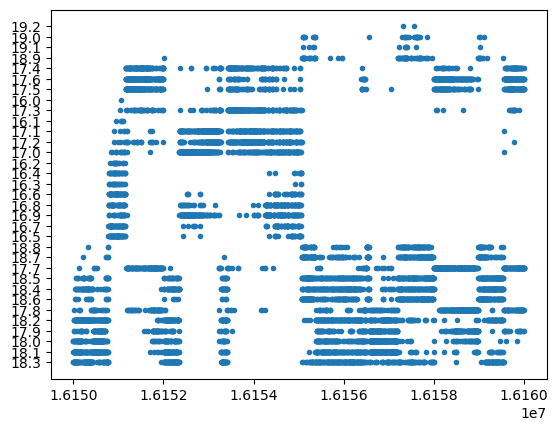

In [188]:
fig, ax = plt.subplots()

N = 10000
n = 1615
ax.plot( df.loc[n*N:N*(n+1), 'mag'], marker='.', linestyle='None' )

In [252]:
n = 1515
df.loc[n*N:N*(n+1)]

,Obstype,artsat,astcat,band,com,ctr,dec,decstar,delay,deltadec,...,seeing,stn,subfmt,subfrm,sys,trkid,trksub,trx,unctime,IAU_designation
15150000,optical,<NA>,Gaia2,G,<NA>,399.0,-0.25637,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000GYgvE,LT7UU7x,<NA>,<NA>,1999 EJ2
15150001,optical,<NA>,Gaia2,G,<NA>,399.0,-0.25524,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000GYgvE,LT7UU7x,<NA>,<NA>,1999 EJ2
15150002,optical,<NA>,Gaia2,G,<NA>,399.0,-0.25247,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000GYgvE,LT7UU7x,<NA>,<NA>,1999 EJ2
15150003,optical,<NA>,Gaia2,G,<NA>,399.0,-0.25100,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000GYgvE,LT7UU7x,<NA>,<NA>,1999 EJ2
15150004,optical,<NA>,Gaia2,G,<NA>,399.0,-0.24983,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000GYgvE,LT7UU7x,<NA>,<NA>,1999 EJ2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15159996,optical,<NA>,Gaia2,G,<NA>,399.0,35.86951,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000Ga2zi,LT9bp7m,<NA>,<NA>,1999 GB19
15159997,optical,<NA>,Gaia2,G,<NA>,399.0,35.87284,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000Ga2zi,LT9bp7m,<NA>,<NA>,1999 GB19
15159998,optical,<NA>,Gaia2,G,<NA>,399.0,35.87558,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000Ga2zi,LT9bp7m,<NA>,<NA>,1999 GB19
15159999,optical,<NA>,Gaia2,G,<NA>,399.0,35.87883,None,<NA>,None,...,None,C57,A17,None,ICRF_KM,00000Ga2zi,LT9bp7m,<NA>,<NA>,1999 GB19


In [230]:
import rocks

sc = rocks.Rock(137805)
print( f" da/dt = {sc.parameters.dynamical.yarkovsky.dadt.value} {sc.parameters.dynamical.yarkovsky.dadt.unit} " )
print( f"   uncertainty = {sc.parameters.dynamical.yarkovsky.dadt.error.max}" )
print( " from " + " ".join(sc.parameters.dynamical.yarkovsky.bibref.shortbib) )


 da/dt = -5.46 10^{-4} au/Myr 
   uncertainty = nan
 from Liu+2023


 da/dt = -5.46 10^{-4} au/Myr 
 from Liu+2023


In [232]:
sc.parameters.dynamical.yarkovsky.dadt

FloatValue(label_='', format_='', symbol_='', description_='', path='parameters.dynamical.yarkovsky.dadt', error=Error(min=nan, max=nan), value=-5.46, error_=nan)